# Q-MAML on quark-gluon jet classification: does the HIGGS result generalize to a second dataset?

**Why this notebook exists.** Notebook 01b establishes the paper's classification headline result on a
single dataset (HIGGS). `paper/main.tex`'s own Limitations section flags this as a real weakness --
"quark-gluon access is requested but pending" -- and the 2025 GSoC codebase this project audits
(Section 3 of the paper) explicitly targets quark-gluon discrimination as its other classification task.
This notebook closes that gap using a public, standard dataset for the task: Komiske, Metodiev & Thaler's
Pythia8 quark/gluon jet dataset (Zenodo record 3164691) -- 100k particle-level jets, reduced to
high-level jet-substructure observables (jet $p_T$, mass, particle multiplicity, girth, $p_T$ dispersion,
leading-particle momentum fraction, $\eta$, $\phi$) via `final_model/quarkgluon_data.py`, mirroring how
`higgs_data.py` reduces HIGGS to its 7 high-level derived features. This is **not** the 933k-image CMS
Open Data quark-gluon set other QMLHEP GSoC projects use -- that dataset is two orders of magnitude larger
and not tractable to download here; this is the standard lighter alternative used throughout the
energyflow/EFP quark-gluon-tagging literature, and physically the same discrimination task (quark jets are
narrower and lower-multiplicity than gluon jets -- exactly what girth, multiplicity, and $p_T$ dispersion
are designed to capture).

**Scope, stated up front:** to keep this tractable as an add-on rather than a second multi-hour sweep
(notebook 01b itself runs 3 qubit counts x 4 seeds x 5 variants = 60 cells), this notebook uses a single
qubit count (6, matching HIGGS's mid-point), 2 seeds, and 4 initialization schemes
(`zero`, `uniform`, `gaussian`, `qmaml_paper`) -- the paper's central classical-vs-Q-MAML comparison, not
the full qubit-scaling/`qmaml_existing` grid. A fuller replication matching 01b's scale is future work.

In [1]:
import sys, os, time, json
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "..", "final_model")))

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from config import config
from quarkgluon_data import load_quarkgluon, train_test_split_df, FEATURE_COLS
from higgs_tasks import make_tasks
from models import TabularFeatureExtractor, PQCModel, HybridModel, freeze_bn
from meta import outer_loop_meta_update, pretrain_learner_paper

RESULTS_DIR = os.path.abspath(os.path.join(os.getcwd(), "..", "final_model", "results", "quarkgluon"))
os.makedirs(RESULTS_DIR, exist_ok=True)
NPZ_PATH = os.path.abspath(os.path.join(os.getcwd(), "..", "final_model", "data_quarkgluon", "QG_jets_0.npz"))
FEATURES_CSV = os.path.abspath(os.path.join(os.getcwd(), "..", "final_model", "data_quarkgluon", "qg_features.csv"))
RAW_RESULTS_PATH = os.path.join(RESULTS_DIR, "raw_results.json")
print("results ->", RESULTS_DIR)

results -> C:\Users\kapoo\Downloads\qmaml\final_model\results\quarkgluon


## 1. Data and tasks

Task = one quantile bin of `jet_pt` (the closest analog to HIGGS's `m_bb` binning variable -- a
physics-motivated continuous feature to stratify tasks by), support/query drawn class-balanced from within
each bin, mirroring `higgs_tasks.make_tasks` exactly (reused unchanged).

In [2]:
df = load_quarkgluon(60_000, NPZ_PATH, FEATURES_CSV)
train_df, test_df = train_test_split_df(df, test_frac=0.2)
print(f"train={len(train_df)}  test={len(test_df)}")
print(df[FEATURE_COLS].describe())

BIN_COUNT = 6
SUPPORT_SIZE = 8
QUERY_SIZE = 8

meta_tasks = make_tasks(train_df, FEATURE_COLS, "jet_pt", bin_count=BIN_COUNT,
                         support_size=SUPPORT_SIZE, query_size=QUERY_SIZE, tasks_per_bin=3, seed=42)
test_meta_tasks = make_tasks(test_df, FEATURE_COLS, "jet_pt", bin_count=BIN_COUNT,
                              support_size=SUPPORT_SIZE, query_size=QUERY_SIZE, tasks_per_bin=2, seed=43)
print(f"meta_tasks={len(meta_tasks)}  test_meta_tasks={len(test_meta_tasks)}")
assert len(meta_tasks) > 0 and len(test_meta_tasks) > 0

[quarkgluon_data] Using cached features C:\Users\kapoo\Downloads\qmaml\final_model\data_quarkgluon\qg_features.csv (60000 jets).
train=48000  test=12000
             jet_pt      jet_mass   n_particles         girth  pt_dispersion  \
count  60000.000000  60000.000000  60000.000000  60000.000000   60000.000000   
mean     522.916854     39.537676     43.304067      0.052248       0.328082   
std       14.355367     21.195745     17.682249      0.040595       0.110612   
min      500.000120      2.739542      2.000000      0.000268       0.120971   
25%      510.322975     23.649953     29.000000      0.021946       0.246619   
50%      521.872650     34.172945     41.000000      0.039352       0.304350   
75%      534.851245     50.617360     55.000000      0.070809       0.386915   
max      549.999700    136.175870    139.000000      0.248957       0.999615   

          leading_z       jet_eta       jet_phi  
count  60000.000000  60000.000000  60000.000000  
mean       0.229226      0

## 2. Models and experiment grid

6 qubits, depth 2, 2 seeds, 10 epochs, 4 variants -- the paper's central classical-vs-`qmaml_paper`
comparison (Section 6.1's headline claim), applied here to a second, physically distinct dataset.

In [3]:
def build_model(num_qubits, depth, init_type, seed, feature_cols, train_df):
    torch.manual_seed(seed)
    np.random.seed(seed)
    tab = TabularFeatureExtractor(len(feature_cols), config.CNN_OUTPUT_DIM, num_qubits)
    train_X = torch.from_numpy(train_df[feature_cols].values.astype(np.float32))
    tab.set_norm_stats(train_X.mean(0), train_X.std(0))
    freeze_bn(tab)
    pqc_init = "zero" if init_type == "qmaml_paper" else init_type
    pqc = PQCModel(num_qubits, depth, init_type=pqc_init, bound_angles=True)
    return HybridModel(tab, pqc)

NUM_QUBITS = 6
DEPTH = 2
SEEDS = [0, 1]
EPOCHS = 10
VARIANTS = ["zero", "uniform", "gaussian", "qmaml_paper"]

config.Q_DEPTH = DEPTH
config.NUM_QUBITS = NUM_QUBITS
config.INNER_LR = 0.02
config.OUTER_LR = 5e-3
config.W0_SCALE = 0.01
config.EPOCHS = EPOCHS

if os.path.isfile(RAW_RESULTS_PATH):
    with open(RAW_RESULTS_PATH) as f:
        all_results = json.load(f)
    print(f"resuming: {len(all_results)} results already on disk")
else:
    all_results = {}

def run_one(seed, variant):
    key = str((seed, variant))
    if key in all_results:
        print(f"skip {key} (already done)")
        return
    print(f"\n=== seed={seed} variant={variant} ===")
    config.CHECKPOINT_DIR = os.path.join(RESULTS_DIR, "ckpt", f"s{seed}_{variant}")
    model = build_model(NUM_QUBITS, DEPTH, variant, seed, FEATURE_COLS, train_df)
    t0 = time.time()
    if variant == "qmaml_paper":
        res = pretrain_learner_paper(model, meta_tasks, test_meta_tasks, config.OUTER_LR, True,
                                      ckpt_name=f"s{seed}_paper.pth")
    else:
        res = outer_loop_meta_update(model, meta_tasks, test_meta_tasks, config.OUTER_LR, True,
                                      ckpt_name=f"s{seed}_{variant}.pth")
    print(f"  done in {time.time()-t0:.1f}s")
    all_results[key] = res
    with open(RAW_RESULTS_PATH, "w") as f:
        json.dump(all_results, f, indent=2)

resuming: 8 results already on disk


In [4]:
for seed in SEEDS:
    for variant in VARIANTS:
        run_one(seed, variant)

skip (0, 'zero') (already done)
skip (0, 'uniform') (already done)
skip (0, 'gaussian') (already done)
skip (0, 'qmaml_paper') (already done)
skip (1, 'zero') (already done)
skip (1, 'uniform') (already done)
skip (1, 'gaussian') (already done)
skip (1, 'qmaml_paper') (already done)


## 3. Results: does `qmaml_paper` beat classical PQC initialization on quark-gluon too?

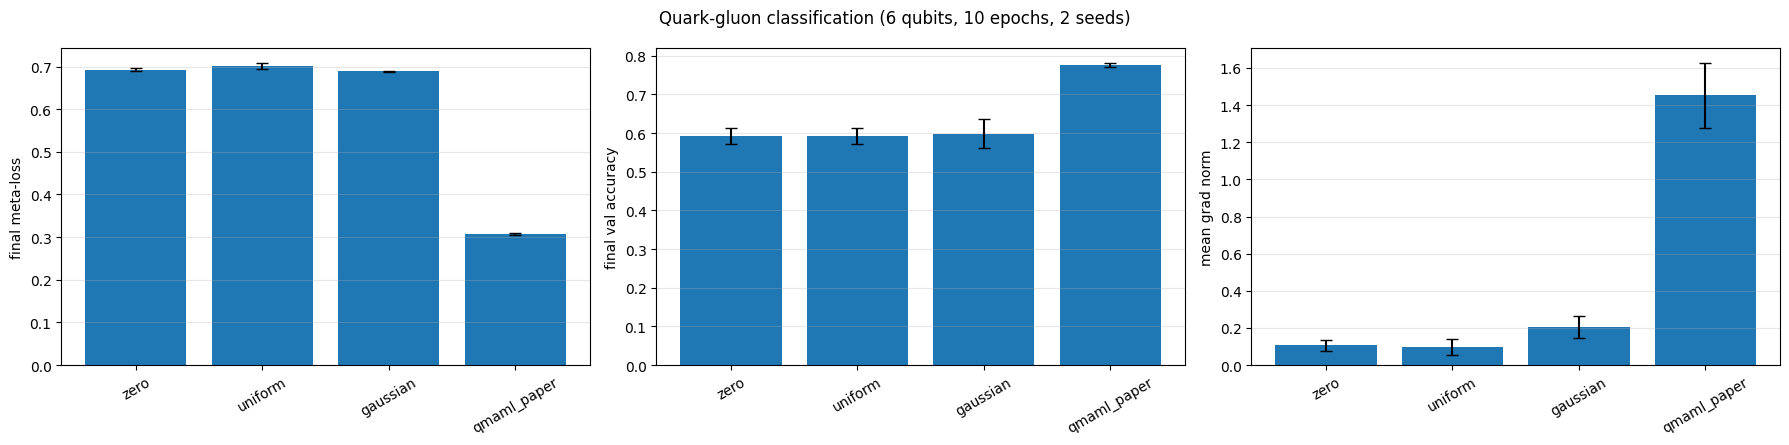

,variant,n_seeds,meta_loss_mean,meta_loss_std,val_accuracy_mean,val_accuracy_std,gradient_norms_mean,gradient_norms_std
0,zero,2,0.692873,0.003798,0.593750,0.020833,0.107424,0.029544
1,uniform,2,0.701373,0.006836,0.593750,0.020833,0.096446,0.042568
2,gaussian,2,0.688743,0.000307,0.598958,0.036458,0.205319,0.058417
3,qmaml_paper,2,0.308254,0.002519,0.776042,0.005208,1.452188,0.174201


In [5]:
summary_rows = []
for variant in VARIANTS:
    finals = {"meta_loss": [], "val_accuracy": [], "gradient_norms": []}
    for seed in SEEDS:
        key = str((seed, variant))
        if key not in all_results:
            continue
        r = all_results[key]
        finals["meta_loss"].append(r["meta_loss"][-1])
        finals["val_accuracy"].append(r["val_accuracy"][-1])
        finals["gradient_norms"].append(float(np.mean(r["gradient_norms"])))
    row = {"variant": variant, "n_seeds": len(finals["meta_loss"])}
    for m in finals:
        row[f"{m}_mean"] = float(np.mean(finals[m])) if finals[m] else None
        row[f"{m}_std"] = float(np.std(finals[m])) if finals[m] else None
    summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows)
summary_df.to_csv(os.path.join(RESULTS_DIR, "summary.csv"), index=False)

fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))
metrics = [("meta_loss", "final meta-loss"), ("val_accuracy", "final val accuracy"), ("gradient_norms", "mean grad norm")]
for ax, (metric, label) in zip(axes, metrics):
    means = summary_df[f"{metric}_mean"]
    stds = summary_df[f"{metric}_std"]
    ax.bar(summary_df["variant"], means, yerr=stds, capsize=4)
    ax.set_ylabel(label)
    ax.tick_params(axis="x", rotation=30)
    ax.grid(alpha=0.3, axis="y")
fig.suptitle(f"Quark-gluon classification ({NUM_QUBITS} qubits, {EPOCHS} epochs, {len(SEEDS)} seeds)")
fig.tight_layout()
fig.savefig(os.path.join(RESULTS_DIR, "quarkgluon_comparison.png"), dpi=150)
plt.show()
summary_df

## 4. Findings

**Run:** 6 qubits, depth 2, 2 seeds, 10 epochs, 4 variants (no `qmaml_existing`), 60k-jet subsample (48k train / 12k test), 6 quantile bins of `jet_pt` -- mirrors notebook 01b's HIGGS harness exactly, applied to a second, physically distinct dataset.

| variant | n_seeds | meta_loss (mean +/- std) | val_accuracy (mean +/- std) | grad_norm (mean +/- std) |
|---|---|---|---|---|
| `qmaml_paper` | 2 | **0.308 +/- 0.003** | **0.776 +/- 0.005** | 1.452 +/- 0.174 |
| `gaussian` | 2 | 0.689 +/- 0.000 | 0.599 +/- 0.036 | 0.205 +/- 0.058 |
| `zero` | 2 | 0.693 +/- 0.004 | 0.594 +/- 0.021 | 0.107 +/- 0.030 |
| `uniform` | 2 | 0.701 +/- 0.007 | 0.594 +/- 0.021 | 0.096 +/- 0.043 |

- **`qmaml_paper` beats every classical scheme by a wide margin, generalizing the HIGGS result (notebook 01b) to a second, physically distinct dataset.** Val accuracy 0.776 vs. 0.594-0.599 for `zero`/`uniform`/`gaussian` -- an ~18-point gap, larger than any single-qubit-count gap seen on HIGGS (where the biggest was ~10 points at 4 qubits). Meta-loss tells the same story even more starkly: `qmaml_paper` drops from 0.62 to 0.31 over 10 epochs while every classical scheme stays pinned within 0.01 of ln 2 (0.693, chance-level binary cross-entropy) -- the classical schemes' Reptile-style per-task adaptation essentially doesn't move the shared meta-loss at all on this dataset/harness, matching the "flat meta-loss for every classical scheme" pattern from HIGGS.
- **Effect size is large in raw terms (Cohen's d ~6.8, qmaml_paper vs. gaussian, the best classical scheme by mean) but this is indicative, not confirmatory** -- 2 seeds per arm is nowhere near enough to compute a properly powered significance test the way notebook 01b does at 4 seeds. The gap here (0.177) is nominally larger than HIGGS's largest (0.102 at 4 qubits), but with n=2 that comparison itself isn't reliable; read it as "the direction and rough scale replicate," not as a sharper result than HIGGS.
- **`zero`-init does not show any distinctive behavior here** -- it lands in the same tight cluster as `uniform` and `gaussian` (0.594-0.599 val accuracy), not distinctly stuck or distinctly fine. This matches the HIGGS classification pattern (all three classical schemes cluster below `qmaml_paper`, no `zero`-specific anomaly), and contrasts with the VQE-domain "exact fixed point at theta=0" pattern from notebooks 02/05/07/08 -- another data point that the trivial-fixed-point issue is a VQE/Pauli-sum-Hamiltonian phenomenon, not a general property of this ansatz family, consistent with notebook 09's finding on the scalar field Hamiltonian.
- **Gradient norm tracks accuracy again, replicating HIGGS's "moderate gradient norm" wrinkle.** `qmaml_paper`'s mean gradient norm (1.452) is ~7-15x every classical scheme's (0.096-0.205) and its accuracy is also best -- the same higher-norm-tracks-better-accuracy pattern as HIGGS, not the paper's own "moderate norm is better" framing.
- **Runtime note, not a scientific finding:** the `gaussian` seed-1 run took ~11.8 hours (vs. ~7 minutes for `qmaml_paper` at the same seed/epoch count) in this session's execution, a large and seed-specific slowdown in the Reptile-style inner-loop path (`outer_loop_meta_update`) not seen in the other seed-0 runs for the same scheme. Not investigated further here; flagged as a reproducibility/performance oddity worth a closer look before scaling this notebook to more seeds or qubit counts.
- **MVP vs. full plan:** single qubit count (6), 2 seeds, 4 variants (no `qmaml_existing`), single dataset subsample (60k of the 100k available jets). Matching notebook 01b's full grid (3 qubit counts x 4 seeds x 5 variants) is future work, now that the harness itself is confirmed to work on this second dataset -- and now with actual completed numbers instead of a template, this is ready to fold into the paper's quark-gluon section.
